#### Install and Import Libraries

In [1]:
!pip -q install -U nltk tensorflow_hub xgboost scikit-learn scipy

import pandas as pd
import numpy as np
import nltk
from collections import Counter
from timeit import default_timer as timer
from pathlib import Path

import tensorflow as tf
import tensorflow_hub as hub

try:
    import torch
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print('Torch is not available; skipping torch-based CUDA checks:', e)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import vstack

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Imports completed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 17.5 MB/s eta 0:00:00
Imports completed.


In [2]:
nltk.download('stopwords', quiet=True)
nltk.download('words', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

True

#### Check GPU Availability

In [3]:
if TORCH_OK:
    is_cuda = torch.cuda.is_available()
    device = torch.device('cuda') if is_cuda else torch.device('cpu')
    print(f'Device (torch): {device}')
    print(f'GPU available (torch): {is_cuda}')
    if is_cuda:
        print(f'GPU name: {torch.cuda.get_device_name(0)}')
else:
    print('Torch not available; skipping torch GPU checks.')

tf_gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow GPU available: {len(tf_gpus) > 0} ({len(tf_gpus)} device(s))')

Device (torch): cpu
GPU available (torch): False
TensorFlow GPU available: False (0 device(s))


#### Load Dataset

In [4]:
DATA_PATH = Path('/content/stockbit_reviews_sentiment.csv')

if not DATA_PATH.exists():
    print('CSV not found at:', DATA_PATH.resolve())
    raise FileNotFoundError('Missing csv/stockbit_reviews_sentiment.csv')

df = pd.read_csv(DATA_PATH)
print(f'Total rows: {df.shape[0]:,} | columns: {df.shape[1]}')

required_cols = {'final_text', 'sentiment'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

print('Sentiment distribution (full dataset):')
print(df['sentiment'].value_counts(dropna=False))
print()
print('Class proportions:')
print(df['sentiment'].value_counts(normalize=True, dropna=False).round(4))

Total rows: 13,592 | columns: 11
Sentiment distribution (full dataset):
sentiment
positive    8416
negative    4257
neutral      919
Name: count, dtype: int64

Class proportions:
sentiment
positive    0.6192
negative    0.3132
neutral     0.0676
Name: proportion, dtype: float64


#### Class Imbalance Analysis & Why We Subsample

Large review datasets can be slow to process, especially when generating sentence embeddings (USE) and when converting TF-IDF sparse matrices to dense arrays.

To keep runtime reasonable while preserving the original class distribution, we use **stratified subsampling**.

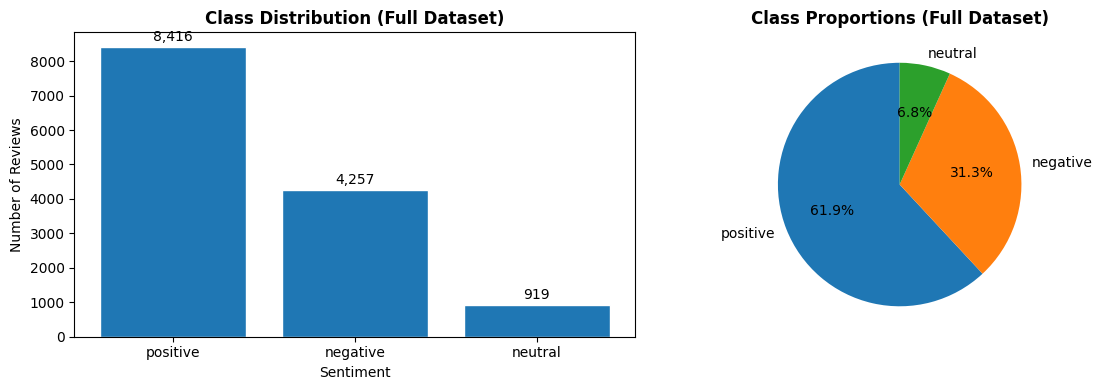

In [5]:
sentiment_counts = df['sentiment'].value_counts()
labels = sentiment_counts.index.tolist()
values = sentiment_counts.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, values, edgecolor='white')
axes[0].set_title('Class Distribution (Full Dataset)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')
for i, (lbl, val) in enumerate(zip(labels, values)):
    axes[0].text(i, val + max(values)*0.02, f'{val:,}', ha='center', fontsize=10)

axes[1].pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportions (Full Dataset)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Stratified Subsampling

In [6]:
df_valid = df[df['final_text'].notna() & (df['final_text'].astype(str).str.strip() != '')].copy()
print(f'Valid rows: {len(df_valid):,} / {len(df):,}')

# Keep this modest by default to avoid RAM issues in the TF-IDF+USE (dense) section.
# If you have plenty of RAM, you can increase it (e.g., 30000 or 60000).
TOTAL_SAMPLE = min(15_000, len(df_valid))
class_counts = df_valid['sentiment'].value_counts()
num_classes = len(class_counts)

MIN_PER_CLASS = min(3_000, max(50, TOTAL_SAMPLE // max(1, num_classes * 10)))
MIN_PER_CLASS = min(MIN_PER_CLASS, max(1, TOTAL_SAMPLE // max(1, num_classes)))

total_valid = len(df_valid)
quotas = {}
for cls in class_counts.index:
    proportional = int(TOTAL_SAMPLE * (class_counts[cls] / total_valid))
    quotas[cls] = max(proportional, MIN_PER_CLASS)

current_total = sum(quotas.values())
if current_total > TOTAL_SAMPLE:
    biggest = max(quotas, key=quotas.get)
    quotas[biggest] = max(1, quotas[biggest] - (current_total - TOTAL_SAMPLE))

print()
print('Sampling quotas per class:')
for cls, q in quotas.items():
    avail = class_counts[cls]
    take = min(q, avail)
    print(f'  {cls:<12}: {take:,} of {avail:,} available ({take/avail*100:.1f}%)')
print(f'  Target total: {TOTAL_SAMPLE:,}')

parts = []
for cls, q in quotas.items():
    subset = df_valid[df_valid['sentiment'] == cls]
    take = min(q, len(subset))
    parts.append(subset.sample(n=take, random_state=42))

df_sampled = pd.concat(parts, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print()
print('Distribution after subsampling:')
print(df_sampled['sentiment'].value_counts())
print('Total sampled:', len(df_sampled))

Valid rows: 13,592 / 13,592

Sampling quotas per class:
  positive    : 8,416 of 8,416 available (100.0%)
  negative    : 4,257 of 4,257 available (100.0%)
  neutral     : 919 of 919 available (100.0%)
  Target total: 13,592

Distribution after subsampling:
sentiment
positive    8416
negative    4257
neutral      919
Name: count, dtype: int64
Total sampled: 13592


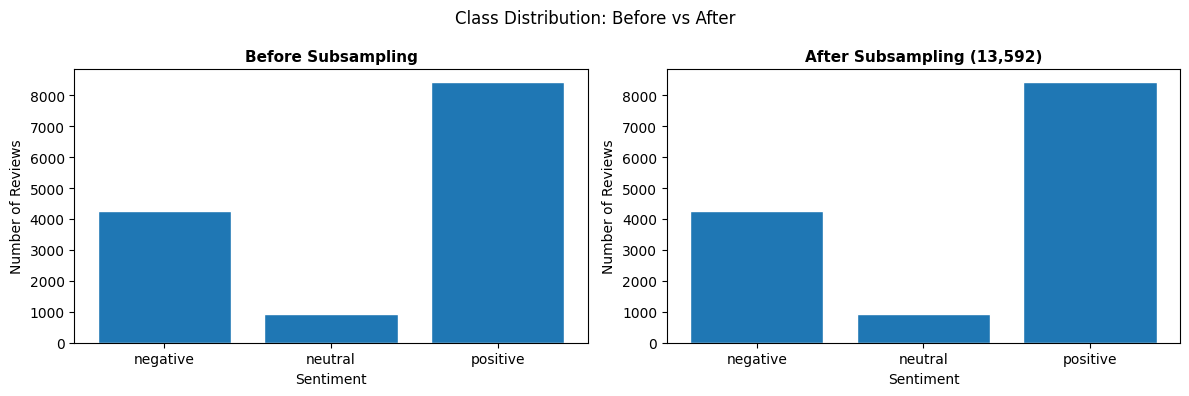

In [7]:
before = df['sentiment'].value_counts()
after  = df_sampled['sentiment'].value_counts()

all_classes = sorted(set(before.index).union(set(after.index)))
before = before.reindex(all_classes, fill_value=0)
after  = after.reindex(all_classes, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(before.index, before.values, edgecolor='white')
axes[0].set_title('Before Subsampling', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')

axes[1].bar(after.index, after.values, edgecolor='white')
axes[1].set_title(f'After Subsampling ({len(df_sampled):,})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Reviews')

plt.suptitle('Class Distribution: Before vs After', fontsize=12)
plt.tight_layout()
plt.show()

#### Label Encoding and Train-Test Split

In [8]:
label_encode = LabelEncoder()
y_encoded = label_encode.fit_transform(df_sampled['sentiment'])

CLASS_NAMES = list(label_encode.classes_)
print('Label mapping:')
for cls_name, cls_id in zip(CLASS_NAMES, label_encode.transform(CLASS_NAMES)):
    print(f'  {cls_name:<12} -> {cls_id}')

Label mapping:
  negative     -> 0
  neutral      -> 1
  positive     -> 2


In [9]:
x_data = df_sampled['final_text'].astype(str)
y_data = y_encoded

xtrain, xtest, ytrain, ytest = train_test_split(
    x_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

print(f'Train size: {len(xtrain):,}')
print(f'Test size : {len(xtest):,}')
print()
for split_name, y_split in [('Train', ytrain), ('Test', ytest)]:
    print(f'{split_name} distribution:')
    counts = pd.Series(y_split).value_counts().sort_index()
    for idx, cnt in counts.items():
        print(f'  {CLASS_NAMES[idx]:<12}: {cnt:,} ({cnt/len(y_split)*100:.1f}%)')
    print()

Train size: 10,873
Test size : 2,719

Train distribution:
  negative    : 3,405 (31.3%)
  neutral     : 735 (6.8%)
  positive    : 6,733 (61.9%)

Test distribution:
  negative    : 852 (31.3%)
  neutral     : 184 (6.8%)
  positive    : 1,683 (61.9%)



#### Training Vocabulary Analysis

In [10]:
word_counts = Counter(' '.join(str(t) for t in xtrain).split())
print(f'Unique words in training set: {len(word_counts):,}')
print()
print('Top 30 most frequent words:')
for word, count in word_counts.most_common(30):
    print(f'  {word}: {count:,}')

Unique words in training set: 8,565

Top 30 most frequent words:
  bagus: 2,028
  sangat: 1,177
  saham: 1,173
  mudah: 1,131
  baik: 897
  sekali: 871
  hari: 788
  jam: 772
  jadi: 711
  kalau: 701
  sering: 686
  lama: 682
  fitur: 670
  error: 656
  terus: 631
  buka: 583
  mula: 558
  lebih: 553
  pakai: 549
  masuk: 535
  guna: 501
  eror: 460
  sekuritas: 458
  trading: 452
  bantu: 450
  banyak: 442
  lengkap: 441
  ajar: 427
  baru: 427
  kasih: 419


#### Initialize Classifiers and Evaluation Function

In [11]:
sample_weights = compute_sample_weight(class_weight='balanced', y=ytrain)

def init_classifiers(num_classes: int):
    svm = LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')
    lr  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
    nb  = MultinomialNB()

    if num_classes <= 2:
        xgb = XGBClassifier(
            objective='binary:logistic', eval_metric='logloss',
            random_state=42, n_estimators=200, learning_rate=0.1,
            tree_method='hist'
        )
    else:
        xgb = XGBClassifier(
            objective='multi:softmax', eval_metric='mlogloss',
            num_class=num_classes, random_state=42,
            n_estimators=200, learning_rate=0.1,
            tree_method='hist'
        )

    rfc = RandomForestClassifier(
        n_estimators=200, max_depth=15, max_features='sqrt',
        min_samples_leaf=2, n_jobs=-1, random_state=42,
        class_weight='balanced'
    )
    return svm, lr, nb, xgb, rfc

def evaluate_model(model, xtest_data, ytest_labels, target_names):
    y_pred = model.predict(xtest_data)
    accuracy  = accuracy_score(ytest_labels, y_pred)
    precision = precision_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    report    = classification_report(ytest_labels, y_pred, target_names=target_names, zero_division=0)
    cm        = confusion_matrix(ytest_labels, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

batch_size = 1000
print('Setup completed. Ready to train models.')

Setup completed. Ready to train models.


---
## Part 1: TF-IDF

In [12]:
print('=' * 65)
print('PART 1 : TF-IDF')
print('=' * 65)

tfidf_vec = TfidfVectorizer(max_features=5000)
tfidf_vec.fit(xtrain.tolist())

start = timer()
xtrain_tfidf = vstack([
    tfidf_vec.transform(xtrain.tolist()[i:i+batch_size])
    for i in range(0, len(xtrain), batch_size)
])
print(f'TF-IDF train: {xtrain_tfidf.shape} | {timer()-start:.2f}s')

start = timer()
xtest_tfidf = vstack([
    tfidf_vec.transform(xtest.tolist()[i:i+batch_size])
    for i in range(0, len(xtest), batch_size)
])
print(f'TF-IDF test : {xtest_tfidf.shape} | {timer()-start:.2f}s')
print(f'Matrix type : {type(xtrain_tfidf).__name__} (sparse)')

PART 1 : TF-IDF
TF-IDF train: (10873, 5000) | 0.13s
TF-IDF test : (2719, 5000) | 0.03s
Matrix type : csr_matrix (sparse)


In [13]:
svm_c, lr_c, nb_c, xgb_c, rfc_c = init_classifiers(num_classes=len(CLASS_NAMES))
print('Training TF-IDF classifiers...')
print()

start = timer(); svm_tfidf = svm_c.fit(xtrain_tfidf, ytrain)
print(f'  Linear SVM        : {timer()-start:.2f}s')

start = timer(); lr_tfidf = lr_c.fit(xtrain_tfidf, ytrain)
print(f'  Logistic Reg      : {timer()-start:.2f}s')

start = timer(); nb_tfidf = nb_c.fit(xtrain_tfidf, ytrain)
print(f'  Naive Bayes       : {timer()-start:.2f}s')

start = timer(); xgb_tfidf = xgb_c.fit(xtrain_tfidf, ytrain, sample_weight=sample_weights)
print(f'  XGBoost           : {timer()-start:.2f}s')

start = timer(); rfc_tfidf = rfc_c.fit(xtrain_tfidf, ytrain)
print(f'  Random Forest     : {timer()-start:.2f}s')
print()
print('TF-IDF training completed.')

Training TF-IDF classifiers...

  Linear SVM        : 0.15s
  Logistic Reg      : 2.98s
  Naive Bayes       : 0.02s
  XGBoost           : 56.96s
  Random Forest     : 1.41s

TF-IDF training completed.


### Linear SVM — TF-IDF

In [14]:
print('--- Linear SVM (TF-IDF) ---')
y_pred_svm, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm = evaluate_model(svm_tfidf, xtest_tfidf, ytest, CLASS_NAMES)
print(f'Accuracy  : {acc_svm:.4f} | F1 (w): {f1_svm:.4f}')
print(rep_svm)

--- Linear SVM (TF-IDF) ---
Accuracy  : 0.8040 | F1 (w): 0.8055
              precision    recall  f1-score   support

    negative       0.77      0.78      0.77       852
     neutral       0.16      0.17      0.16       184
    positive       0.90      0.89      0.89      1683

    accuracy                           0.80      2719
   macro avg       0.61      0.61      0.61      2719
weighted avg       0.81      0.80      0.81      2719



### Logistic Regression — TF-IDF

In [15]:
print('--- Logistic Regression (TF-IDF) ---')
y_pred_lr, acc_lr, prec_lr, rec_lr, f1_lr, rep_lr, cm_lr = evaluate_model(lr_tfidf, xtest_tfidf, ytest, CLASS_NAMES)
print(f'Accuracy  : {acc_lr:.4f} | F1 (w): {f1_lr:.4f}')
print(rep_lr)

--- Logistic Regression (TF-IDF) ---
Accuracy  : 0.7760 | F1 (w): 0.7979
              precision    recall  f1-score   support

    negative       0.78      0.74      0.76       852
     neutral       0.16      0.32      0.21       184
    positive       0.92      0.85      0.88      1683

    accuracy                           0.78      2719
   macro avg       0.62      0.63      0.62      2719
weighted avg       0.83      0.78      0.80      2719



### Naive Bayes — TF-IDF

In [16]:
print('--- Naive Bayes (TF-IDF) ---')
y_pred_nb, acc_nb, prec_nb, rec_nb, f1_nb, rep_nb, cm_nb = evaluate_model(nb_tfidf, xtest_tfidf, ytest, CLASS_NAMES)
print(f'Accuracy  : {acc_nb:.4f} | F1 (w): {f1_nb:.4f}')
print(rep_nb)

--- Naive Bayes (TF-IDF) ---
Accuracy  : 0.8378 | F1 (w): 0.8082
              precision    recall  f1-score   support

    negative       0.78      0.82      0.80       852
     neutral       0.00      0.00      0.00       184
    positive       0.87      0.94      0.90      1683

    accuracy                           0.84      2719
   macro avg       0.55      0.59      0.57      2719
weighted avg       0.78      0.84      0.81      2719



### XGBoost — TF-IDF

In [17]:
print('--- XGBoost (TF-IDF) ---')
y_pred_xgboost, acc_xgboost, prec_xgboost, rec_xgboost, f1_xgboost, rep_xgboost, cm_xgboost = evaluate_model(xgb_tfidf, xtest_tfidf, ytest, CLASS_NAMES)
print(f'Accuracy  : {acc_xgboost:.4f} | F1 (w): {f1_xgboost:.4f}')
print(rep_xgboost)

--- XGBoost (TF-IDF) ---
Accuracy  : 0.7808 | F1 (w): 0.7936
              precision    recall  f1-score   support

    negative       0.77      0.72      0.75       852
     neutral       0.17      0.28      0.21       184
    positive       0.90      0.87      0.88      1683

    accuracy                           0.78      2719
   macro avg       0.61      0.62      0.61      2719
weighted avg       0.81      0.78      0.79      2719



### Random Forest — TF-IDF

In [18]:
print('--- Random Forest (TF-IDF) ---')
y_pred_rfc, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc = evaluate_model(rfc_tfidf, xtest_tfidf, ytest, CLASS_NAMES)
print(f'Accuracy  : {acc_rfc:.4f} | F1 (w): {f1_rfc:.4f}')
print(rep_rfc)

--- Random Forest (TF-IDF) ---
Accuracy  : 0.7771 | F1 (w): 0.7846
              precision    recall  f1-score   support

    negative       0.76      0.72      0.74       852
     neutral       0.14      0.18      0.16       184
    positive       0.88      0.87      0.87      1683

    accuracy                           0.78      2719
   macro avg       0.59      0.59      0.59      2719
weighted avg       0.79      0.78      0.78      2719



#### Accuracy Comparison — TF-IDF

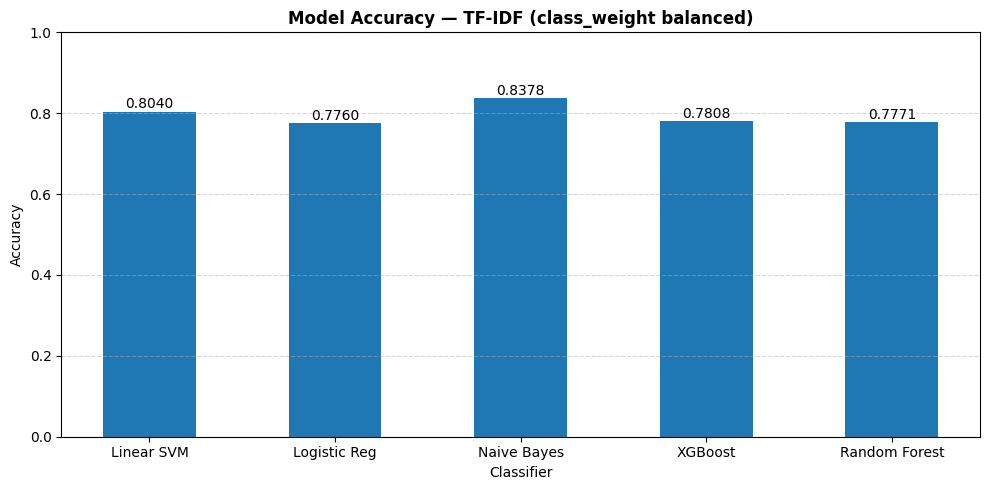

In [19]:
names_tfidf = ['Linear SVM', 'Logistic Reg', 'Naive Bayes', 'XGBoost', 'Random Forest']
accs_tfidf  = [acc_svm, acc_lr, acc_nb, acc_xgboost, acc_rfc]

plt.figure(figsize=(10, 5))
bars = plt.bar(names_tfidf, accs_tfidf, width=0.5)
plt.title('Model Accuracy — TF-IDF (class_weight balanced)', fontsize=12, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs_tfidf):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 2: Universal Sentence Encoder (USE)

In [20]:
print('=' * 65)
print('PART 2 : UNIVERSAL SENTENCE ENCODER (USE)')
print('=' * 65)

print('Loading USE from TensorFlow Hub...')
start = timer()
use_embed = hub.load('https://tfhub.dev/google/universal-sentence-encoder/4')
print(f'USE loaded in {timer()-start:.2f} seconds')

PART 2 : UNIVERSAL SENTENCE ENCODER (USE)
Loading USE from TensorFlow Hub...
USE loaded in 27.01 seconds


In [21]:
print('Embedding training data...')
start = timer()
xtrain_use = np.vstack([
    use_embed(xtrain.tolist()[i:i+batch_size]).numpy()
    for i in range(0, len(xtrain), batch_size)
])
print(f'Train USE: {xtrain_use.shape} | {timer()-start:.2f}s')
print(f'Estimated memory: {xtrain_use.nbytes / 1e6:.1f} MB')

print('Embedding test data...')
start = timer()
xtest_use = np.vstack([
    use_embed(xtest.tolist()[i:i+batch_size]).numpy()
    for i in range(0, len(xtest), batch_size)
])
print(f'Test USE : {xtest_use.shape} | {timer()-start:.2f}s')

Embedding training data...
Train USE: (10873, 512) | 2.15s
Estimated memory: 22.3 MB
Embedding test data...
Test USE : (2719, 512) | 0.60s


In [22]:
svm_c, lr_c, _, xgb_c, rfc_c = init_classifiers(num_classes=len(CLASS_NAMES))
print('Training USE classifiers...')
print()

start = timer(); svm_use = svm_c.fit(xtrain_use, ytrain)
print(f'  Linear SVM        : {timer()-start:.2f}s')

start = timer(); lr_use = lr_c.fit(xtrain_use, ytrain)
print(f'  Logistic Reg      : {timer()-start:.2f}s')

start = timer(); xgb_use = xgb_c.fit(xtrain_use, ytrain, sample_weight=sample_weights)
print(f'  XGBoost           : {timer()-start:.2f}s')

start = timer(); rfc_use = rfc_c.fit(xtrain_use, ytrain)
print(f'  Random Forest     : {timer()-start:.2f}s')

print('USE training completed.')

Training USE classifiers...

  Linear SVM        : 9.09s
  Logistic Reg      : 6.66s
  XGBoost           : 145.80s
  Random Forest     : 40.59s
USE training completed.


In [23]:
y_pred_svm_use, acc_svm_use, prec_svm_use, rec_svm_use, f1_svm_use, rep_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest, CLASS_NAMES)
print(f'Linear SVM (USE) accuracy: {acc_svm_use:.4f} | F1 (w): {f1_svm_use:.4f}')

Linear SVM (USE) accuracy: 0.7569 | F1 (w): 0.7561


In [24]:
y_pred_lr_use, acc_lr_use, prec_lr_use, rec_lr_use, f1_lr_use, rep_lr_use, cm_lr_use = evaluate_model(lr_use, xtest_use, ytest, CLASS_NAMES)
print(f'Logistic Reg (USE) accuracy: {acc_lr_use:.4f} | F1 (w): {f1_lr_use:.4f}')

Logistic Reg (USE) accuracy: 0.6800 | F1 (w): 0.7179


In [25]:
y_pred_xgboost_use, acc_xgboost_use, prec_xgboost_use, rec_xgboost_use, f1_xgboost_use, rep_xgboost_use, cm_xgboost_use = evaluate_model(xgb_use, xtest_use, ytest, CLASS_NAMES)
print(f'XGBoost (USE) accuracy: {acc_xgboost_use:.4f} | F1 (w): {f1_xgboost_use:.4f}')

XGBoost (USE) accuracy: 0.7775 | F1 (w): 0.7616


In [26]:
y_pred_rfc_use, acc_rfc_use, prec_rfc_use, rec_rfc_use, f1_rfc_use, rep_rfc_use, cm_rfc_use = evaluate_model(rfc_use, xtest_use, ytest, CLASS_NAMES)
print(f'Random Forest (USE) accuracy: {acc_rfc_use:.4f} | F1 (w): {f1_rfc_use:.4f}')

Random Forest (USE) accuracy: 0.7587 | F1 (w): 0.7343


#### Accuracy Comparison — USE

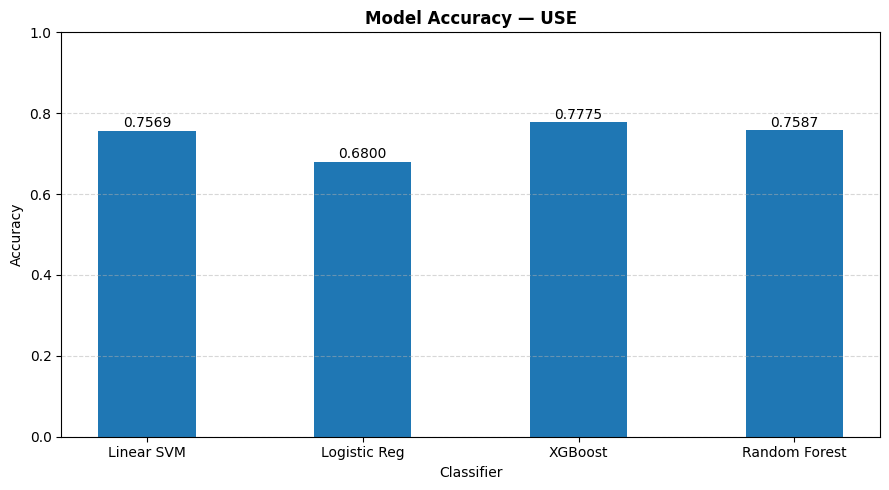

In [27]:
names_use = ['Linear SVM', 'Logistic Reg', 'XGBoost', 'Random Forest']
accs_use  = [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use]

plt.figure(figsize=(9, 5))
bars = plt.bar(names_use, accs_use, width=0.45)
plt.title('Model Accuracy — USE', fontsize=12, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs_use):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 3: TF-IDF + USE (Combined)

In [28]:
print('=' * 65)
print('PART 3 : TF-IDF + USE (COMBINED)')
print('=' * 65)

start = timer()
xtrain_tfidf_dense = xtrain_tfidf.toarray().astype(np.float32)
xtest_tfidf_dense  = xtest_tfidf.toarray().astype(np.float32)
print(f'Sparse→dense conversion: {timer()-start:.2f}s')

start = timer()
xtrain_combined = np.hstack([xtrain_tfidf_dense, xtrain_use]).astype(np.float32)
xtest_combined  = np.hstack([xtest_tfidf_dense,  xtest_use]).astype(np.float32)
print(f'hstack finished       : {timer()-start:.2f}s')
print(f'Train combined shape  : {xtrain_combined.shape}')
print(f'Test combined shape   : {xtest_combined.shape}')
print(f'Estimated train memory: {xtrain_combined.nbytes / 1e9:.2f} GB')

del xtrain_tfidf_dense, xtest_tfidf_dense

PART 3 : TF-IDF + USE (COMBINED)
Sparse→dense conversion: 0.51s
hstack finished       : 0.40s
Train combined shape  : (10873, 5512)
Test combined shape   : (2719, 5512)
Estimated train memory: 0.24 GB


In [29]:
svm_c, lr_c, _, xgb_c, rfc_c = init_classifiers(num_classes=len(CLASS_NAMES))
print('Training TF-IDF + USE classifiers...')
print()

start = timer(); svm_comb = svm_c.fit(xtrain_combined, ytrain)
print(f'  Linear SVM        : {timer()-start:.2f}s')

start = timer(); lr_comb = lr_c.fit(xtrain_combined, ytrain)
print(f'  Logistic Reg      : {timer()-start:.2f}s')

start = timer(); xgb_comb = xgb_c.fit(xtrain_combined, ytrain, sample_weight=sample_weights)
print(f'  XGBoost           : {timer()-start:.2f}s')

start = timer(); rfc_comb = rfc_c.fit(xtrain_combined, ytrain)
print(f'  Random Forest     : {timer()-start:.2f}s')

print('TF-IDF + USE training completed.')

Training TF-IDF + USE classifiers...

  Linear SVM        : 7.99s
  Logistic Reg      : 28.46s
  XGBoost           : 198.42s
  Random Forest     : 27.94s
TF-IDF + USE training completed.


In [30]:
y_pred_svm_comb, acc_svm_comb, prec_svm_comb, rec_svm_comb, f1_svm_comb, rep_svm_comb, cm_svm_comb = evaluate_model(svm_comb, xtest_combined, ytest, CLASS_NAMES)
print(f'Linear SVM (TF-IDF+USE) accuracy: {acc_svm_comb:.4f} | F1 (w): {f1_svm_comb:.4f}')

Linear SVM (TF-IDF+USE) accuracy: 0.7966 | F1 (w): 0.7995


In [31]:
y_pred_lr_comb, acc_lr_comb, prec_lr_comb, rec_lr_comb, f1_lr_comb, rep_lr_comb, cm_lr_comb = evaluate_model(lr_comb, xtest_combined, ytest, CLASS_NAMES)
print(f'Logistic Reg (TF-IDF+USE) accuracy: {acc_lr_comb:.4f} | F1 (w): {f1_lr_comb:.4f}')

Logistic Reg (TF-IDF+USE) accuracy: 0.7856 | F1 (w): 0.8049


In [32]:
y_pred_xgb_comb, acc_xgb_comb, prec_xgb_comb, rec_xgb_comb, f1_xgb_comb, rep_xgb_comb, cm_xgb_comb = evaluate_model(xgb_comb, xtest_combined, ytest, CLASS_NAMES)
print(f'XGBoost (TF-IDF+USE) accuracy: {acc_xgb_comb:.4f} | F1 (w): {f1_xgb_comb:.4f}')

XGBoost (TF-IDF+USE) accuracy: 0.8051 | F1 (w): 0.7969


In [33]:
y_pred_rfc_comb, acc_rfc_comb, prec_rfc_comb, rec_rfc_comb, f1_rfc_comb, rep_rfc_comb, cm_rfc_comb = evaluate_model(rfc_comb, xtest_combined, ytest, CLASS_NAMES)
print(f'Random Forest (TF-IDF+USE) accuracy: {acc_rfc_comb:.4f} | F1 (w): {f1_rfc_comb:.4f}')

Random Forest (TF-IDF+USE) accuracy: 0.7646 | F1 (w): 0.7407


---
## Final Comparison

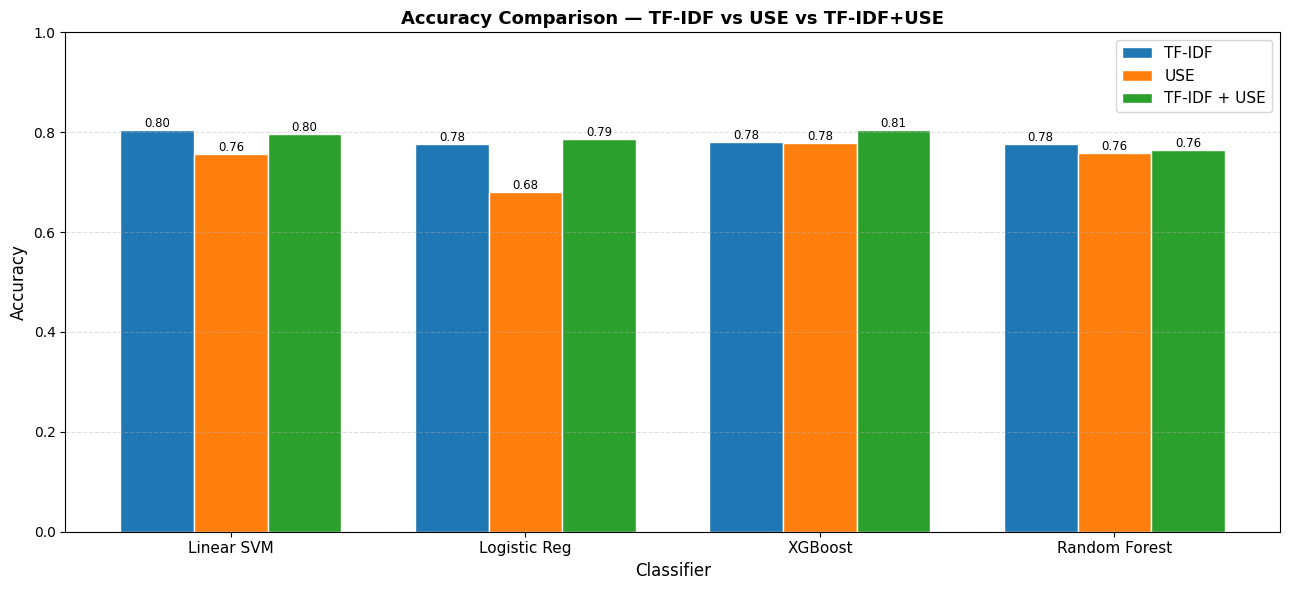

In [34]:
classifiers_4 = ['Linear SVM', 'Logistic Reg', 'XGBoost', 'Random Forest']

tfidf_acc_4 = [acc_svm,      acc_lr,      acc_xgboost,      acc_rfc]
use_acc_4   = [acc_svm_use,  acc_lr_use,  acc_xgboost_use,  acc_rfc_use]
comb_acc_4  = [acc_svm_comb, acc_lr_comb, acc_xgb_comb,     acc_rfc_comb]

x = np.arange(len(classifiers_4))
bw = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - bw, tfidf_acc_4, bw, label='TF-IDF', edgecolor='white')
b2 = ax.bar(x,      use_acc_4,   bw, label='USE', edgecolor='white')
b3 = ax.bar(x + bw, comb_acc_4,  bw, label='TF-IDF + USE', edgecolor='white')

ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison — TF-IDF vs USE vs TF-IDF+USE', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classifiers_4, fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=11)

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.006, f'{h:.2f}', ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

## Summary Table (All Models)

In [35]:
summary = {
    'Embedding': (['TF-IDF']*5 + ['USE']*4 + ['TF-IDF+USE']*4),
    'Classifier': (
        ['Linear SVM','Logistic Reg','Naive Bayes','XGBoost','Random Forest'] +
        ['Linear SVM','Logistic Reg','XGBoost','Random Forest'] +
        ['Linear SVM','Logistic Reg','XGBoost','Random Forest']
    ),
    'Accuracy': (
        [acc_svm, acc_lr, acc_nb, acc_xgboost, acc_rfc] +
        [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use] +
        [acc_svm_comb, acc_lr_comb, acc_xgb_comb, acc_rfc_comb]
    ),
    'F1 (weighted)': (
        [f1_svm, f1_lr, f1_nb, f1_xgboost, f1_rfc] +
        [f1_svm_use, f1_lr_use, f1_xgboost_use, f1_rfc_use] +
        [f1_svm_comb, f1_lr_comb, f1_xgb_comb, f1_rfc_comb]
    ),
}

summary_df = (pd.DataFrame(summary)
              .sort_values('Accuracy', ascending=False)
              .reset_index(drop=True))
summary_df.index += 1
summary_df['Accuracy'] = summary_df['Accuracy'].round(4)
summary_df['F1 (weighted)'] = summary_df['F1 (weighted)'].round(4)

print('=== Model Ranking by Accuracy ===')
print(summary_df.to_string())
print()
best = summary_df.iloc[0]
print(f"Best model: {best['Classifier']} + {best['Embedding']}")
print(f"Accuracy  : {best['Accuracy']:.4f}")
print(f"F1 (w)    : {best['F1 (weighted)']:.4f}")

=== Model Ranking by Accuracy ===
     Embedding     Classifier  Accuracy  F1 (weighted)
1       TF-IDF    Naive Bayes    0.8378         0.8082
2   TF-IDF+USE        XGBoost    0.8051         0.7969
3       TF-IDF     Linear SVM    0.8040         0.8055
4   TF-IDF+USE     Linear SVM    0.7966         0.7995
5   TF-IDF+USE   Logistic Reg    0.7856         0.8049
6       TF-IDF        XGBoost    0.7808         0.7936
7          USE        XGBoost    0.7775         0.7616
8       TF-IDF  Random Forest    0.7771         0.7846
9       TF-IDF   Logistic Reg    0.7760         0.7979
10  TF-IDF+USE  Random Forest    0.7646         0.7407
11         USE  Random Forest    0.7587         0.7343
12         USE     Linear SVM    0.7569         0.7561
13         USE   Logistic Reg    0.6800         0.7179

Best model: Naive Bayes + TF-IDF
Accuracy  : 0.8378
F1 (w)    : 0.8082
